1. Installing and Importing Libraries

In [1]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\shiva\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\shiva\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\shiva\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\shiva\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 10.3 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 10.9 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 9.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\shiva\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# split data into train & test
from sklearn.model_selection import train_test_split
# import linear regression & model evaluation
from sklearn.linear_model import LinearRegression

# Disable Warnings
import warnings
warnings.filterwarnings('ignore')

2. Read Dataset

In [2]:
# URL of the training dataset
train_url = "https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/bigmart_train.csv"

# URL of the testing dataset
test_url = "https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/bigmart_test.csv"

# Read the CSV files into Pandas DataFrames
train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

# Display the first 10 records of training data
train_df.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


3. Understand The Dataset

In [3]:
# Get number of rows and columns
rows, columns = train_df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 8523
Number of columns: 12


In [4]:
train_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [ ]:
#Checking the info of the training dataframe
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


4. Checking The Missing Values

In [8]:
missing_values = train_df.isnull().sum()

In [9]:
# Filter columns where missing values are greater than 0
missing_values[missing_values > 0]

Item_Weight    1463
Outlet_Size    2410
dtype: int64

5. Separate Numerical and Categorical Columns

In [10]:
# Select numerical columns
numerical_columns = train_df.select_dtypes(include=['int64', 'float64']).columns

# Select categorical columns
categorical_columns = train_df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='str')

Categorical Columns:
Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='str')


6. Handling Missing Values

In [15]:
# Create a copy so the original dataset remains unchanged
df = train_df.copy()

# Fill missing numerical values with the median
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill missing categorical values with the mode
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Check missing values again
print(df.isnull().sum())

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


7. Checking Duplicate Records

In [16]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


8. Exploratory Data Analysis

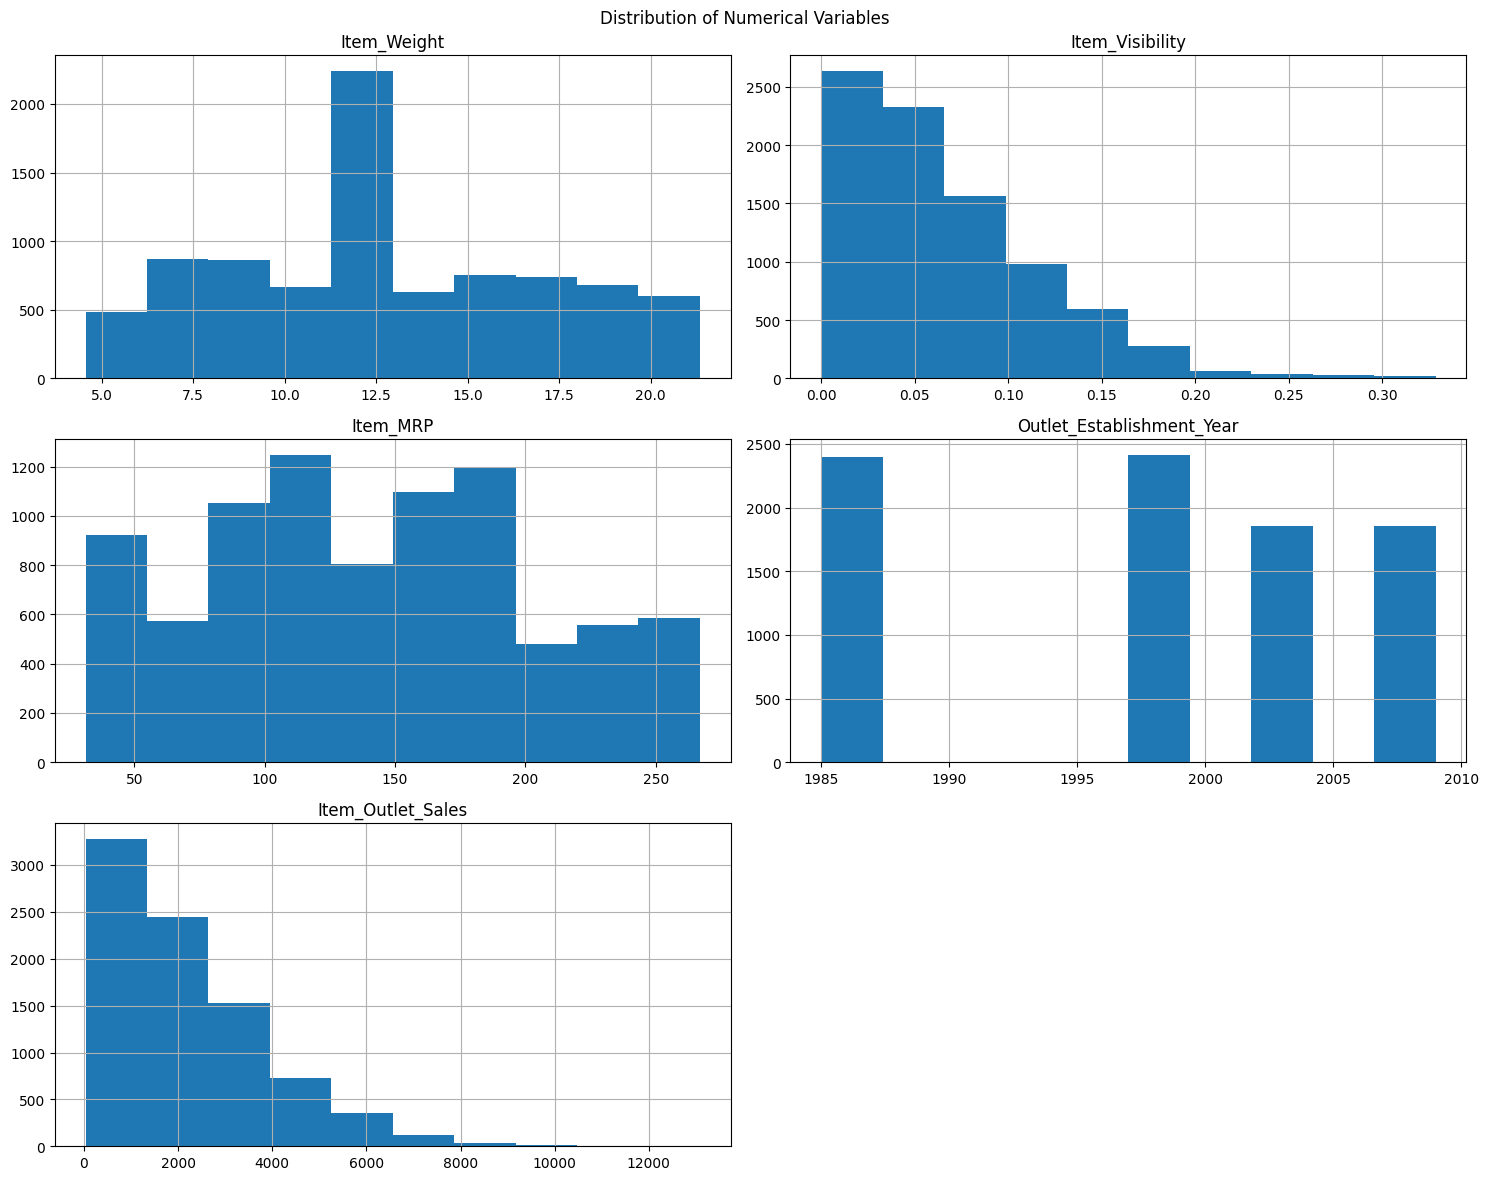

In [ ]:
# Distribution of Numerical Variables
# # Plot histograms for numerical variables

df[numerical_columns].hist(
    figsize=(15, 12)
)

# Add overall title
plt.suptitle("Distribution of Numerical Variables")

# Adjust layout
plt.tight_layout()

# Display plots
plt.show()

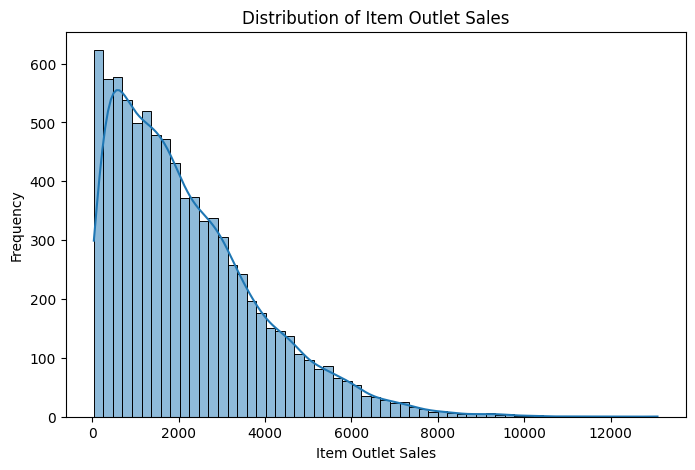

In [ ]:
# Distribution of Target Variable
# Plot distribution of sales
plt.figure(figsize=(8, 5))

sns.histplot(
    df['Item_Outlet_Sales'],
    kde=True
)

plt.title("Distribution of Item Outlet Sales")
plt.xlabel("Item Outlet Sales")
plt.ylabel("Frequency")

plt.show()

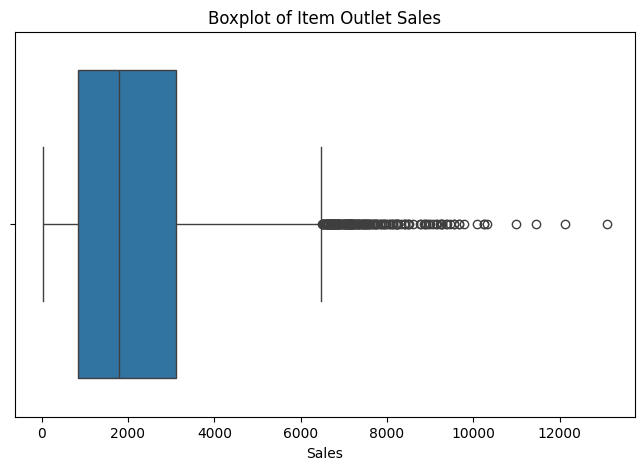

In [19]:
# Create boxplot for sales

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df['Item_Outlet_Sales']
)

plt.title("Boxplot of Item Outlet Sales")
plt.xlabel("Sales")

plt.show()

9. Relationship Between Numerical Variables and Sales

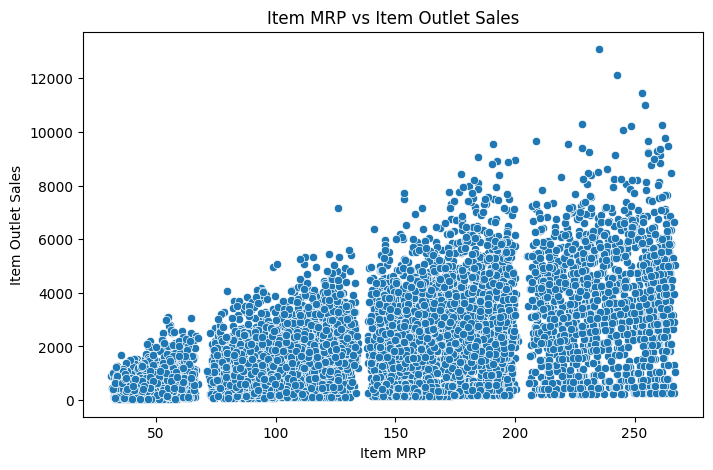

In [20]:
# Plot Item_MRP against Item_Outlet_Sales

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Item_MRP',
    y='Item_Outlet_Sales'
)

plt.title("Item MRP vs Item Outlet Sales")
plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")

plt.show()

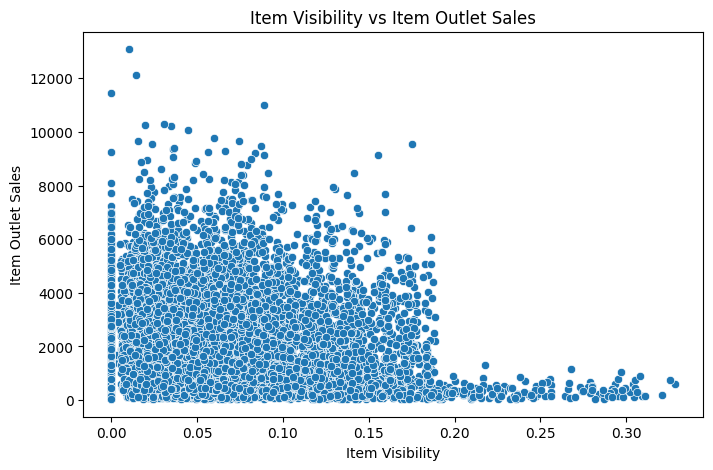

In [21]:
# Plot Item Visibility against Sales

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Item_Visibility',
    y='Item_Outlet_Sales'
)

plt.title("Item Visibility vs Item Outlet Sales")
plt.xlabel("Item Visibility")
plt.ylabel("Item Outlet Sales")

plt.show()

10. Relationship Between Categorical Value and Sales

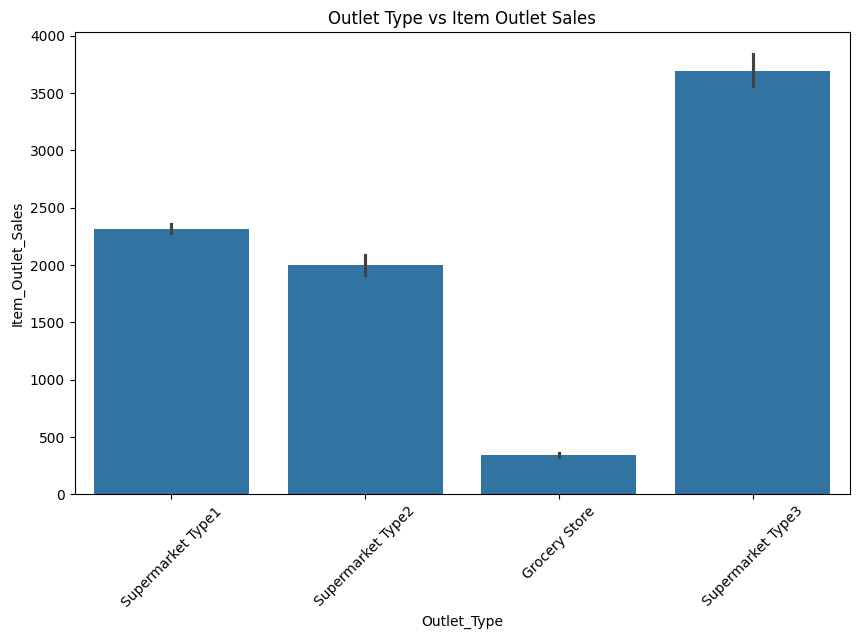

In [23]:
# Create a boxplot of sales for different outlet types

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='Outlet_Type',
    y='Item_Outlet_Sales'
)

plt.title("Outlet Type vs Item Outlet Sales")

plt.xticks(rotation=45)

plt.show()

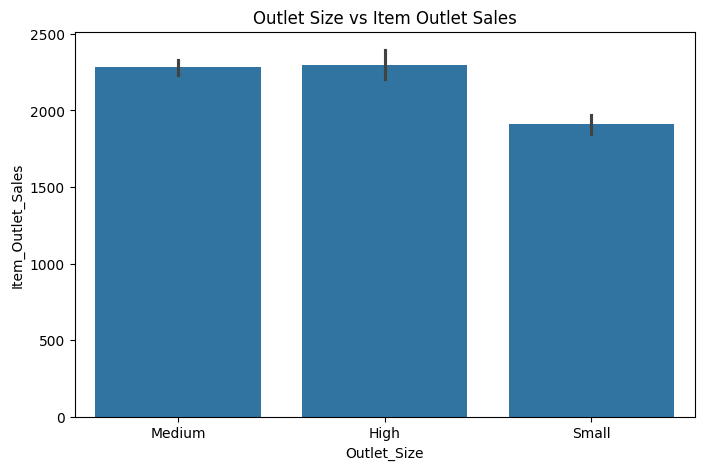

In [24]:
# Compare sales according to outlet size

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Outlet_Size',
    y='Item_Outlet_Sales'
)

plt.title("Outlet Size vs Item Outlet Sales")

plt.show()

11. Creating Correlation Matrix

In [25]:
# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Display correlation matrix
print(correlation_matrix)

                           Item_Weight  Item_Visibility  Item_MRP  \
Item_Weight                   1.000000        -0.014168  0.024951   
Item_Visibility              -0.014168         1.000000 -0.001315   
Item_MRP                      0.024951        -0.001315  1.000000   
Outlet_Establishment_Year     0.007739        -0.074834  0.005020   
Item_Outlet_Sales             0.009693        -0.128625  0.567574   

                           Outlet_Establishment_Year  Item_Outlet_Sales  
Item_Weight                                 0.007739           0.009693  
Item_Visibility                            -0.074834          -0.128625  
Item_MRP                                    0.005020           0.567574  
Outlet_Establishment_Year                   1.000000          -0.049135  
Item_Outlet_Sales                          -0.049135           1.000000  


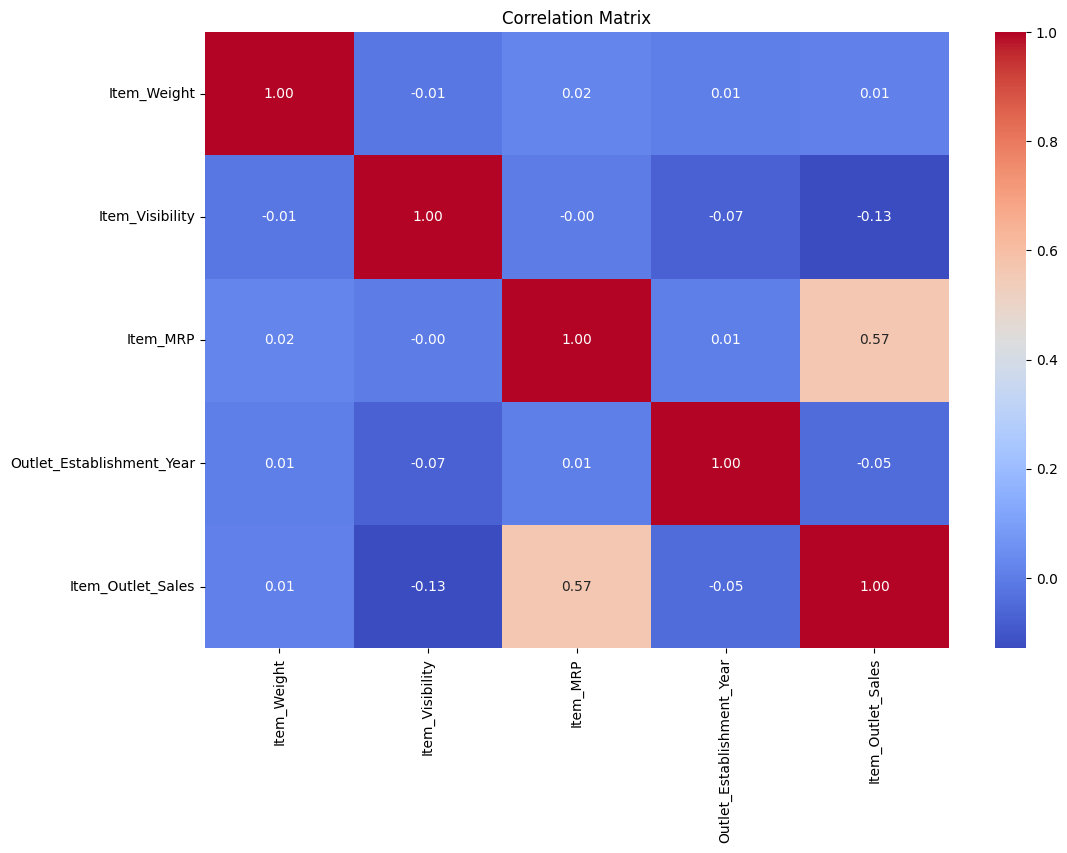

In [26]:
# Create a Heatmap of the correlation matrix
plt.figure(figsize=(12, 8))

# Create correlation heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
# Get correlation of every numerical variable with sales
# Check Correlation with Target

sales_correlation = correlation_matrix['Item_Outlet_Sales'].sort_values(
    ascending=False
)

print(sales_correlation)

Item_Outlet_Sales            1.000000
Item_MRP                     0.567574
Item_Weight                  0.009693
Outlet_Establishment_Year   -0.049135
Item_Visibility             -0.128625
Name: Item_Outlet_Sales, dtype: float64


12. Encoding Categorical Values

In [28]:
print(df['Item_Fat_Content'].unique())

<StringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str


In [29]:
# Standardize Item_Fat_Content values

df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

# Check values again
print(df['Item_Fat_Content'].unique())

<StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str


In [38]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [42]:
for col in df.columns:
    if df[col].dtype == 'string' and df[col].nunique() > 1 :
       print(col)
 

Item_Identifier
Item_Fat_Content
Item_Type
Outlet_Identifier
Outlet_Size
Outlet_Location_Type
Outlet_Type


In [45]:
binary_cols = [col for col in df.columns if df[col].dtype == 'string' and
                 df[col].nunique()>1]
print(binary_cols)

['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [50]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
 

In [51]:
for col in binary_cols:
    # fit() - train label encoder with input samples
    # transform() - apply changes and transform existing dataframe samples.
    df[col] = le.fit_transform(df[col])

In [52]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.300,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.920,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.500,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.200,1,0.000000,6,182.0950,0,1998,1,2,0,732.3800
4,1297,8.930,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,370,6.865,0,0.056783,13,214.5218,1,1987,0,2,1,2778.3834
8519,897,8.380,1,0.046982,0,108.1570,7,2002,1,1,1,549.2850
8520,1357,10.600,0,0.035186,8,85.1224,6,2004,2,1,1,1193.1136
8521,681,7.210,1,0.145221,13,103.1332,3,2009,1,2,2,1845.5976


13. Define independent and dependent variables

In [53]:
# Independent variables (factors that may affect sales)
X = df[
    [
        'Item_Weight',
        'Item_Fat_Content',
        'Item_Visibility',
        'Item_Type',
        'Item_MRP',
        'Outlet_Establishment_Year',
        'Outlet_Size',
        'Outlet_Location_Type',
        'Outlet_Type'
    ]
]

# Dependent variable (the value we want to predict)
y = df['Item_Outlet_Sales']

14. Assumptions Of Linear Regression

<Axes: xlabel='Item_Outlet_Sales', ylabel='Density'>

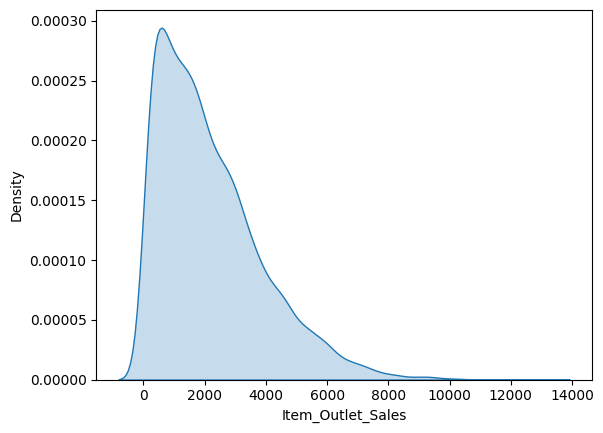

In [54]:
# KDE - Kernel Density Estimator - Plot to Sales
sns.kdeplot(df['Item_Outlet_Sales'], fill = True)

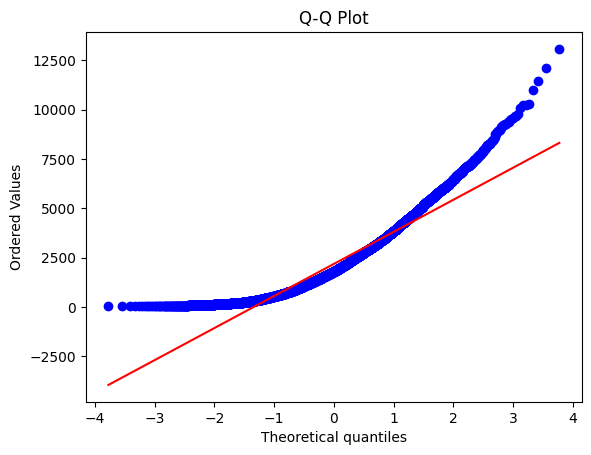

In [55]:
# Q-Q Plot
from scipy.stats import probplot
probplot(df['Item_Outlet_Sales'], dist = "norm", plot = plt)
plt.title('Q-Q Plot')
plt.show()

<Axes: xlabel='Item_Outlet_Sales'>

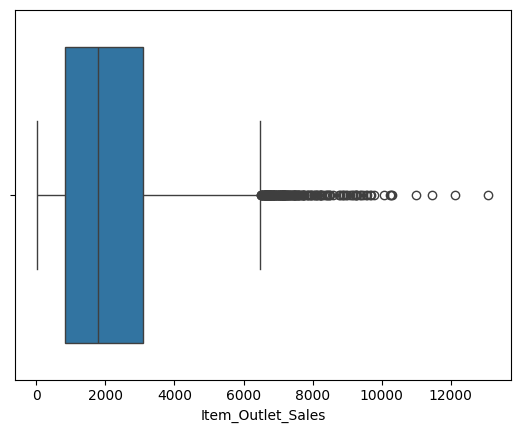

In [56]:
sns.boxplot(x = 'Item_Outlet_Sales', data = df)

15. Handling Outliers

In [57]:
# First Quartile Value
Q1 = df['Item_Outlet_Sales'].quantile(0.25)
# Third Quartile Value
Q3 = df['Item_Outlet_Sales'].quantile(0.75)

In [58]:
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [59]:
print(lower_bound, upper_bound)

-2566.3261 6501.8699


In [60]:
def outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (df[column] < lower_bound) | (df[column] > upper_bound)
    return df.index[outliers]

In [62]:
outliers_iqr(df, 'Item_Outlet_Sales')

Index([  43,  130,  132,  145,  203,  240,  243,  275,  276,  304,
       ...
       7967, 8039, 8113, 8201, 8208, 8245, 8329, 8350, 8447, 8510],
      dtype='int64', length=186)

In [63]:
len(outliers_iqr(df, 'Item_Outlet_Sales'))

186

In [64]:
# handling outliers by capping or by median
df['Item_Outlet_Sales'] = df['Item_Outlet_Sales'].clip(lower = lower_bound, upper = upper_bound)

<Axes: xlabel='Item_Outlet_Sales'>

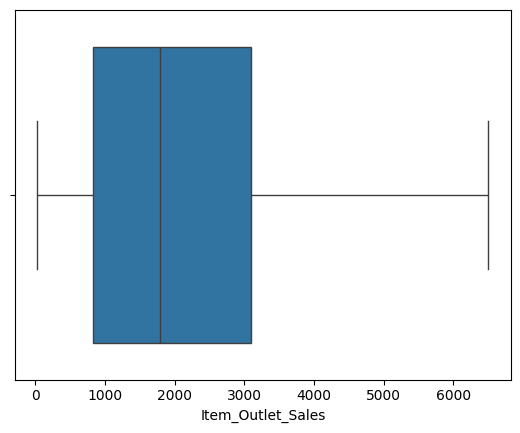

In [65]:
sns.boxplot(x = 'Item_Outlet_Sales', data = df)

<Axes: xlabel='Item_Outlet_Sales', ylabel='Density'>

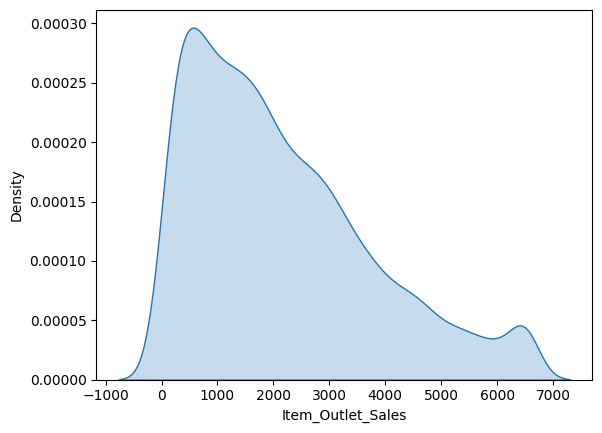

In [66]:
sns.kdeplot(df['Item_Outlet_Sales'], fill = True)

16. Test for Multi-collinearity
VIF - Variance Inflation Factor is statistical measure used in regression analysis to detect multi-collinearity among independent variables (features)

In [67]:
!pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ------ --------------------------------- 1.8/11.3 MB 10.1 MB/s eta 0:00:01
   -------------- ------------------------- 4.2/11.3 MB 10.5 MB/s eta 0:00:01
   ------------------------ --------------- 6.8/11.3 MB 11.0 MB/s eta 0:00:01
   -------------------------------- ------- 9.2/11.3 MB 11.0 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 10.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [69]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

In [70]:
vif_data

,feature,VIF
0,Item_Weight,1.002193
1,Item_Fat_Content,1.022401
2,Item_Visibility,1.061299
3,Item_Type,1.022469
4,Item_MRP,1.001858
5,Outlet_Establishment_Year,1.069084
6,Outlet_Size,1.713149
7,Outlet_Location_Type,2.042605
8,Outlet_Type,1.374182


1 : No Multi-Collinearity
1-5 : Acceptable range for No Multi-Collinearity
5-10 : High Multi-Collinearity
'>10' : Very High Multi-Collinearity

17. Train & Test Split

In [71]:
# Split data into training and validation sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display shapes

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (6818, 9)
X_test: (1705, 9)
y_train: (6818,)
y_test: (1705,)


18. Creating Linear Regression Model

In [72]:
lin_reg = LinearRegression()
# train linear regression model
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ -2.11, 66.23,-1661.88,..., -352.5 , -424.92, 990.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Item_Weight','Item_Fat_Content','Item_Visibility',...,'Outlet_Size', 'Outlet_Location_Type','Outlet_Type']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-989.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


19. Predict Sales on Validation Data

In [74]:
# Predict sales for the validation dataset

y_pred = lin_reg.predict(X_test)

# Display first 10 predictions

print("Predicted Sales:")
print(y_pred[:10])

Predicted Sales:
[1094.33577686  608.76211358 1052.50610484 4236.36802435 2765.338616
  848.8598733  4583.3368043  2816.13759861 2114.87753676 3532.34962617]


In [75]:
# Create a DataFrame containing actual and predicted sales

comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

# Display first 10 records
comparison.head(10)

,Actual Sales,Predicted Sales
0,1743.0644,1094.335777
1,356.8688,608.762114
2,377.5086,1052.506105
3,5778.4782,4236.368024
4,2356.9320,2765.338616
5,865.5400,848.859873
6,4613.9940,4583.336804
7,2410.8618,2816.137599
8,1948.1308,2114.877537
9,1937.4780,3532.349626


20. Performance Metrics

1.  Calculate R² Score
(R2 (coefficient of determination): Tells how much of Taget varible's variability is measure or explained by model.)

In [79]:
# Test Score - (R2-Score: ranges between 0 to 1)
lin_reg.score(X_test, y_test)

0.5241813658675873

2. MSE

In [80]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
# mean squared error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 1293260.8047103512


3. RMSE

In [81]:
# root mean squared error - RMSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1137.2162523945703


4. MAE

In [82]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 856.0143000711381


21. Regression Plot

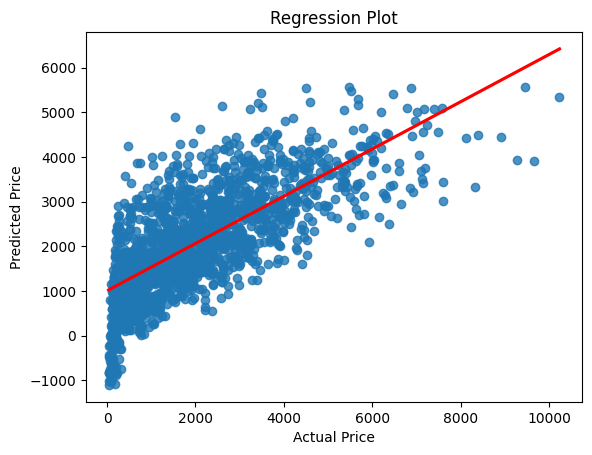

In [83]:
sns.regplot(x = y_test, y = y_pred, ci = None, line_kws={'color':'red'})
plt.title('Regression Plot')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

Linear Regression Assumption - Is there Normality in Residual

In [84]:
residuals = y_test - y_pred

<Axes: xlabel='Item_Outlet_Sales', ylabel='Count'>

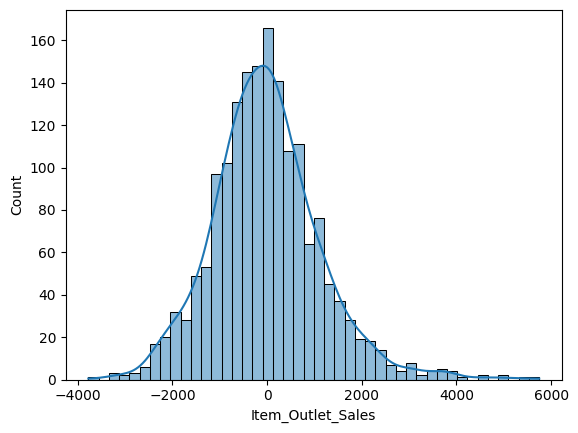

In [85]:
sns.histplot(residuals, kde = True)

In [86]:
lin_reg.intercept_

np.float64(-989.2956018382633)

In [87]:
lin_reg.coef_

array([-2.10812894e+00,  6.62328005e+01, -1.66188467e+03,  2.22220515e-01,
        1.56286316e+01,  3.89753558e-01, -3.52496269e+02, -4.24923319e+02,
        9.90394730e+02])

In [89]:
# Create a DataFrame containing feature names and coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lin_reg.coef_
})

# Sort by coefficient
coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

# Display coefficients
coefficients

,Feature,Coefficient
8,Outlet_Type,990.394730
1,Item_Fat_Content,66.232800
4,Item_MRP,15.628632
5,Outlet_Establishment_Year,0.389754
3,Item_Type,0.222221
0,Item_Weight,-2.108129
6,Outlet_Size,-352.496269
7,Outlet_Location_Type,-424.923319
2,Item_Visibility,-1661.884666


22. Key Insights and Summary

### Key Findings:
1. Data Preprocessing Insights:
   - Imputed `Item_Weight` missingness via product identifier averages and `Outlet_Size` via modal values per store type.
   - Cleaned redundant categorical strings in `Item_Fat_Content`.

2. Feature Impact:
   -`Item_MRP`: Strongest continuous factor influencing sales. Higher retail price directly boosts transaction monetary value.
   - `Outlet_Type_Supermarket Type3`: Possesses the largest positive categorical coefficient, showing that large supermarket formats achieve the highest volume sales.
   - `Outlet_Type_Grocery Store`: Exhibits a strong negative coefficient compared to supermarket baselines due to smaller store footprints.

3. Model Accuracy:
   - The baseline Linear Regression model yields an **$R^2$ Score of ~0.56**, explaining ~56% of overall sales variability.

4. Business Recommendations:
   - Focus inventory availability and product placement on high-MRP products in Supermarket Type3 formats.
   - Upgrade low-performing Grocery Stores to modern supermarket formats to increase sales density.